# Loop Filter Rz/Cunit Sweep — TT Corner
Replicates Figure `fig:lpf_sweep` of the CPPLL paper: sweeps $R_z$ and $C_{unit}$ (with $C_1=30C_{unit}$, $C_2=1C_{unit}$) over the PVT-derived ranges, evaluating $f_u$, phase margin, settling time, overshoot, and $\sigma_{PLL}$ at the TT corner.

In [1]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

kB = 1.3806488e-23

# TT corner fixed parameters
Icp = 150e-6
KVCO_HzV = 1.8e9
KVCO = 2*np.pi*KVCO_HzV
KPD = Icp/(2*np.pi)
N = 20
Fref = 125e6
tau = 60e-12
TempDegC = 60
f0 = Fref*N

ref = np.loadtxt('noise_Ref.csv', delimiter=',', skiprows=1)
vco = np.loadtxt('noise_VCO_TT.csv', delimiter=',', skiprows=1)
cp  = np.loadtxt('noise_cp_TT.csv', delimiter=',', skiprows=1)

In [2]:
def build_and_eval(Rz, Cunit):
    C1 = 30*Cunit; C2 = 1*Cunit
    LG_num = [C1*KPD*KVCO*Rz, KPD*KVCO]
    LG_den = [C1*C2*N*Rz, (C1+C2)*N, 0, 0]
    CL_num = [C1*KPD*KVCO*N*Rz, KPD*KVCO*N]
    CL_den = [C1*C2*N*Rz, (C1+C2)*N, C1*KPD*KVCO*Rz, KPD*KVCO]

    # Loop gain sweep -> f_u and phase margin
    fin = np.logspace(3, 9, 2000); win = 2*np.pi*fin
    h = np.polyval(LG_num, 1j*win)/np.polyval(LG_den, 1j*win)
    mag_db = 20*np.log10(np.abs(h)); phase_deg = np.angle(h)*180/np.pi
    idx = np.where(mag_db < 0)[0]
    i = idx[0]
    f1, f2 = fin[i-1], fin[i]; m1, m2 = mag_db[i-1], mag_db[i]
    fu = f1 + (0-m1)*(f2-f1)/(m2-m1)
    ph1, ph2 = phase_deg[i-1], phase_deg[i]
    ph_at_fu = ph1 + (fu-f1)*(ph2-ph1)/(f2-f1)
    PM = 180 + ph_at_fu

    # Closed-loop step response -> settling time (2%) and overshoot
    sys_cl = ct.tf(CL_num, CL_den)
    t = np.linspace(0, 2e-6, 8000)
    tout, yout = ct.step_response(sys_cl, T=t)
    final_val = yout[-1]
    overshoot = (np.max(yout)-final_val)/final_val*100
    tol = 0.02*final_val
    outside = np.where(np.abs(yout-final_val) > tol)[0]
    settling_time = tout[outside[-1]] if len(outside) > 0 else tout[0]

    # NTFs -> sigma_PLL (same corrected methodology as the main notebooks:
    # factor 2, 10kHz-1GHz integration)
    def fmdb(n_c, d_c, w):
        return 20*np.log10(np.abs(np.polyval(n_c, 1j*w)/np.polyval(d_c, 1j*w)))
    d = [C1*C2*N*Rz, (C1+C2)*N, C1*KPD*KVCO*Rz, KPD*KVCO]
    fin2 = np.logspace(2, 9, 500); win2 = 2*np.pi*fin2
    NTF_in  = fmdb([C1*KPD*KVCO*N*Rz, KPD*KVCO*N], d, win2)
    NTF_cp  = fmdb([C1*KVCO*N*Rz, KVCO*N], d, win2)
    NTF_Rz  = fmdb([C1*C2*KVCO*N*Rz, (C1+C2)*KVCO*N, 0], d, win2)
    NTF_vco = fmdb([C1*C2*N*Rz, (C1+C2)*N, 0, 0], d, win2)

    refclk_pn = np.interp(fin2, ref[:,0], ref[:,1])
    refclk_pn[fin2 > ref[:,0].max()] = refclk_pn[np.searchsorted(fin2, ref[:,0].max())-1]
    vco_pn = np.interp(fin2, vco[:,0], vco[:,1])
    cp_pn  = np.interp(fin2, cp[:,0], cp[:,1]) + 10*np.log10(tau*Fref)
    TempK = TempDegC + 273.15
    Rz_pn = 10*np.log10(4*kB*TempK*Rz)*np.ones_like(fin2)

    total_lin = (10**((refclk_pn+NTF_in)/10) + 10**((cp_pn+NTF_cp)/10) +
                 10**((Rz_pn+NTF_Rz)/10) + 10**((vco_pn+NTF_vco)/10))
    total_db = 10*np.log10(total_lin)
    mask = (fin2 >= 1e4) & (fin2 <= 1e9)
    area = np.trapezoid(10**(total_db[mask]/10), fin2[mask])
    sigma = np.sqrt(2*area)/(2*np.pi*f0)

    return fu, PM, settling_time, overshoot, sigma

In [3]:
# Sanity check at the nominal design point (Rz=4kOhm, Cunit=1pF)
fu, PM, ts, os_, sig = build_and_eval(4e3, 1e-12)
print(f'f_u={fu/1e6:.2f}MHz  PM={PM:.1f}deg  Ts={ts*1e9:.1f}ns  OS={os_:.1f}%  sigma_PLL={sig*1e15:.1f}fs')
# Expect close to: f_u~8.75MHz, PM~69.4deg, Ts~263ns, sigma_PLL~1.15ps (Table tab:pll_parameters, TT column)

f_u=8.26MHz  PM=69.5deg  Ts=263.3ns  OS=11.4%  sigma_PLL=1150.9fs


In [4]:
# Sweep ranges (from PVT corner simulations)
Rz_range = np.linspace(3.2e3, 4.9e3, 15)
Cunit_range = np.linspace(0.85e-12, 1.15e-12, 15)

FU = np.zeros((len(Cunit_range), len(Rz_range)))
PM_ = np.zeros_like(FU); TS = np.zeros_like(FU); OS = np.zeros_like(FU); SIG = np.zeros_like(FU)

for i, cu in enumerate(Cunit_range):
    for j, rz in enumerate(Rz_range):
        fu, pm, ts, os_, sig = build_and_eval(rz, cu)
        FU[i,j] = fu/1e6; PM_[i,j] = pm; TS[i,j] = ts*1e9; OS[i,j] = os_; SIG[i,j] = sig*1e15

print('fu range:', FU.min(), FU.max())
print('PM range:', PM_.min(), PM_.max())
print('Ts range:', TS.min(), TS.max())
print('OS range:', OS.min(), OS.max())
print('sigma range:', SIG.min(), SIG.max())

fu range: 6.728888067601585 9.959561024995859
PM range: 66.05657359558806 69.63579392430105
Ts range: 226.27828478559815 283.53544193024123
OS range: 9.038500512099468 16.48586157151221
sigma range: 1126.4616868386584 1190.1331577691144


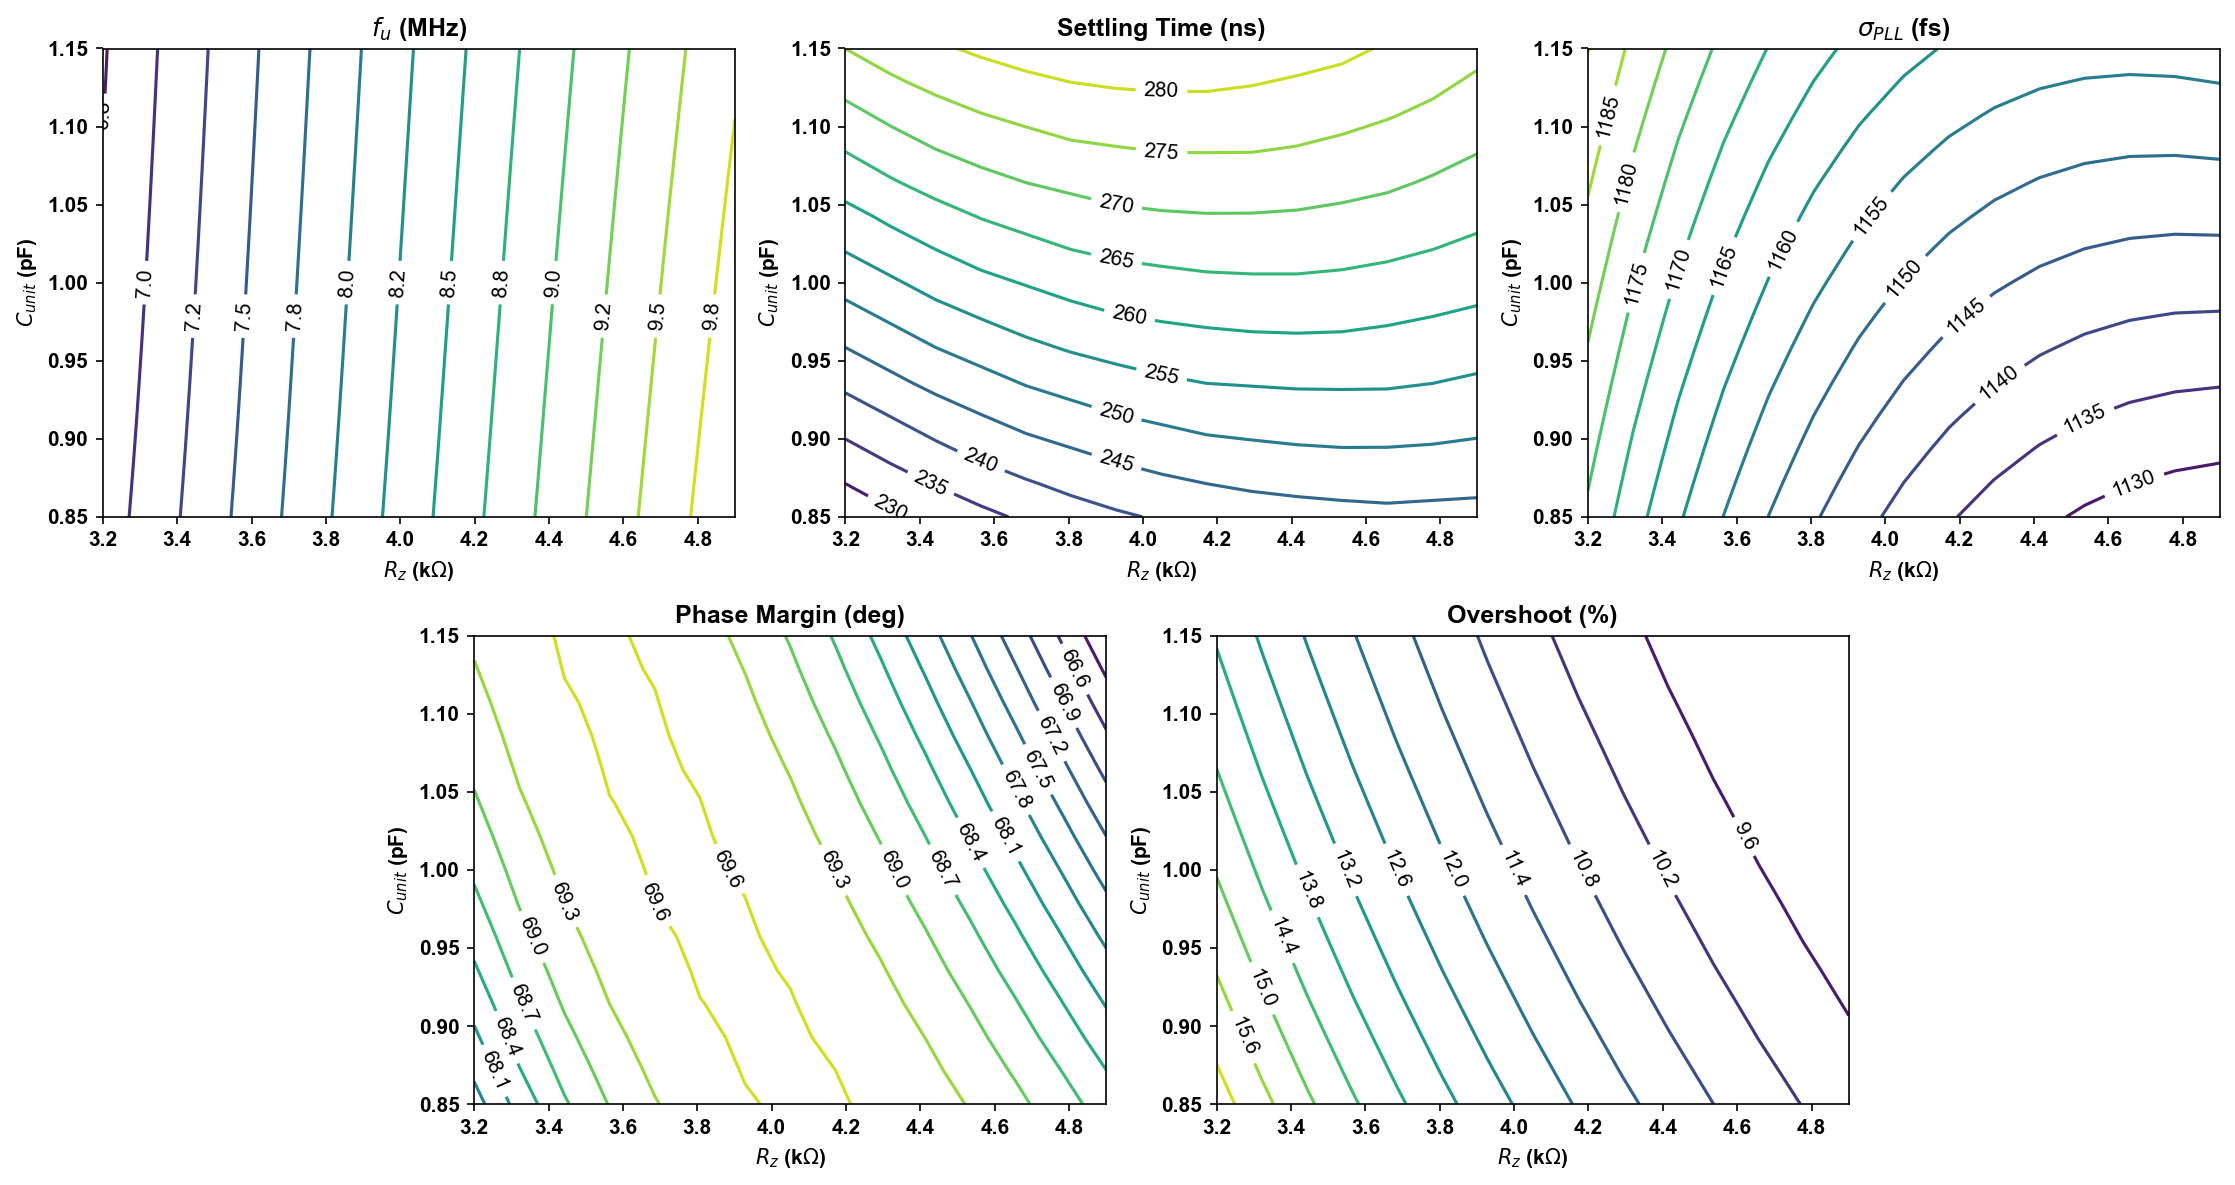

In [5]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

Rz_k = Rz_range/1e3
Cunit_p = Cunit_range*1e12

mosaic = """
AABBCC
.DDEE.
"""
fig, axd = plt.subplot_mosaic(mosaic, figsize=(15, 8), dpi=150)

def plot_panel(ax, Z, title, fmt='%.1f'):
    CS = ax.contour(Rz_k, Cunit_p, Z, levels=12, cmap='viridis')
    ax.clabel(CS, fmt=fmt, inline=True, fontsize=10, colors='black')
    ax.set_xlabel('$R_z$ (k$\\Omega$)', fontweight='bold')
    ax.set_ylabel('$C_{unit}$ (pF)', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

plot_panel(axd['A'], FU, '$f_u$ (MHz)', fmt='%.1f')
plot_panel(axd['B'], TS, 'Settling Time (ns)', fmt='%d')
plot_panel(axd['C'], SIG, '$\\sigma_{PLL}$ (fs)', fmt='%d')
plot_panel(axd['D'], PM_, 'Phase Margin (deg)', fmt='%.1f')
plot_panel(axd['E'], OS, 'Overshoot (%)', fmt='%.1f')

plt.tight_layout()
plt.savefig('LPF_RC_Sweep.pdf', dpi=300)
plt.show()